In [4]:
from google.colab import drive
drive.mount('/content/drive')

# Dezarhivăm folderul direct în memoria super-rapidă a serverului Google
!unzip -q "/content/drive/MyDrive/chest_xrayzip.zip" -d "/content"
print("Datele au fost pregătite cu succes!")

Mounted at /content/drive
Datele au fost pregătite cu succes!


In [5]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
import numpy as np

# 1. Conectarea la folderele tale (pe care le vom urca pe Google Drive)
train_dir = '/content/chest_xray/train'
val_dir = '/content/chest_xray/val'
test_dir = '/content/chest_xray/test'

# 2. Augmentarea Datelor (Echivalentul lui imageDataAugmenter din MATLAB)
train_datagen = ImageDataGenerator(
    rescale=1./255,          # Normalizăm pixelii
    rotation_range=10,       # RandRotation [-10, 10]
    width_shift_range=0.1,   # RandXTranslation
    height_shift_range=0.1   # RandYTranslation
)

# Pentru Validare și Testare NU facem augmentare, doar normalizare
test_datagen = ImageDataGenerator(rescale=1./255)

# Crearea stocurilor de imagini (Echivalentul lui imageDatastore)
train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=(224, 224), batch_size=32, class_mode='binary')

val_generator = test_datagen.flow_from_directory(
    val_dir, target_size=(224, 224), batch_size=32, class_mode='binary')

test_generator = test_datagen.flow_from_directory(
    test_dir, target_size=(224, 224), batch_size=16, class_mode='binary', shuffle=False)

# 3. Pregătirea Rețelei (Transfer Learning)
# Observație: În Keras, ResNet50 este modelul standard inclus, puțin mai puternic decât ResNet18
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Înghețăm straturile de bază ca să nu le distrugem cunoștințele
for layer in base_model.layers:
    layer.trainable = False

# Adăugăm noile straturi la final (Echivalentul lui fullyConnectedLayer și dropoutLayer)
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x) # 1 ieșire pentru Normal/Pneumonie

model = Model(inputs=base_model.input, outputs=predictions)

# 4. Opțiuni de Antrenare (Echivalentul lui trainingOptions din MATLAB)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Calculăm ponderile claselor (Class Weights) pentru a nu fi paranoic
# Presupunem că 0=Normal și 1=Pneumonie. Dăm o importanță mai mare clasei cu mai puține poze.
class_weights = {0: 3.0, 1: 1.0}

# 5. Antrenarea efectivă (Echivalentul lui trainNetwork)
print("Începe antrenarea în Python...")
history = model.fit(
    train_generator,
    epochs=5,
    validation_data=val_generator,
    class_weight=class_weights
)

# 6. Salvarea modelului
# Salvăm modelul DIRECT în Google Drive-ul tău, ca să fie permanent!
model.save('/content/drive/MyDrive/ModelPneumonie_Python.h5')
print("Modelul a fost salvat permanent în Google Drive!")
# 7. Evaluarea Performanței
test_loss, test_acc = model.evaluate(test_generator)
print(f"Acuratețea pe setul de testare în Python: {test_acc * 100:.2f}%")


Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Începe antrenarea în Python...
Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 127s 691ms/step - accuracy: 0.5061 - loss: 1.2040 - val_accuracy: 0.5000 - val_loss: 0.6934
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 109s 667ms/step - accuracy: 0.4893 - loss: 1.1408 - val_accuracy: 0.5000 - val_loss: 0.6906
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 106s 650ms/step - accuracy: 0.5021 - loss: 1.1058 - val_accuracy: 0.5000 - val_loss: 0.6870
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 106s 649ms/step - accuracy: 0.4791 - loss: 1.1045 - val_accuracy: 0.5000 - val_loss: 0.6848
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 105s 642ms/step - accuracy: 0.4979 - loss: 1.0684 - val_accuracy: 0.5625 - val_loss: 0.6817


Modelul a fost salvat permanent în Google Drive!
39/39 ━━━━━━━━━━━━━━━━━━━━ 6s 162ms/step - accuracy: 0.4503 - loss: 0.6894
Acuratețea pe setul de testare în Python: 45.03%


In [6]:
print("Începe faza 2: Fine-Tuning (Reglaj fin)...")

# 1. Dezghețăm rețeaua de bază
base_model.trainable = True

# 2. Înghețăm primele straturi, dar lăsăm ultimele 20 de straturi libere să învețe subtilități medicale
for layer in base_model.layers[:-20]:
    layer.trainable = False

# 3. Re-compilăm modelul, dar cu o Rată de Învățare MULT mai mică (1e-5)
# Asta îi spune să facă pași mici și atenți ca să iasă din "blocajul" de 50%
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# 4. Mai antrenăm pentru 5 epoci
history_fine = model.fit(
    train_generator,
    epochs=5,
    validation_data=val_generator,
    class_weight=class_weights
)

# 5. Evaluăm și salvăm noul model super-performant
test_loss, test_acc = model.evaluate(test_generator)
print(f"Acuratețea DUPĂ Fine-Tuning: {test_acc * 100:.2f}%")

model.save('/content/drive/MyDrive/ModelPneumonie_Python_Optimizat.h5')
print("Modelul optimizat a fost salvat permanent în Google Drive!")

Începe faza 2: Fine-Tuning (Reglaj fin)...
Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 123s 690ms/step - accuracy: 0.4956 - loss: 1.0712 - val_accuracy: 0.6250 - val_loss: 0.6814
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 109s 667ms/step - accuracy: 0.5006 - loss: 1.0555 - val_accuracy: 0.6875 - val_loss: 0.6811
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 143s 674ms/step - accuracy: 0.4931 - loss: 1.0617 - val_accuracy: 0.8750 - val_loss: 0.6808
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 108s 663ms/step - accuracy: 0.5176 - loss: 1.0503 - val_accuracy: 0.8750 - val_loss: 0.6805
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 110s 674ms/step - accuracy: 0.5069 - loss: 1.0543 - val_accuracy: 0.8750 - val_loss: 0.6802
39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 127ms/step - accuracy: 0.5913 - loss: 0.6846


Acuratețea DUPĂ Fine-Tuning: 59.13%
Modelul optimizat a fost salvat permanent în Google Drive!


In [7]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

print("Începem Soluția Optimizată: Antrenare completă și curată...")

# 1. Curățăm memoria serverului ca să nu se încurce cu modelul vechi
tf.keras.backend.clear_session()

# 2. Aducem un ResNet50 proaspăt și îl lăsăm COMPLET DEZGHEȚAT de la prima epocă
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = True

# 3. Adăugăm straturile noastre finale
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x) # Previne memorarea mecanică (Overfitting)
predictions = Dense(1, activation='sigmoid')(x)

model_optim = Model(inputs=base_model.input, outputs=predictions)

# 4. Folosim un Learning Rate FOARTE mic (1e-5) pentru a nu strica "inteligența" din fabrică a lui ResNet
model_optim.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# 5. Antrenăm modelul (FĂRĂ class weights, lăsăm rețeaua să descopere singură tiparele)
history_optim = model_optim.fit(
    train_generator,
    epochs=5,
    validation_data=val_generator
)

# 6. Evaluăm și salvăm
test_loss, test_acc = model_optim.evaluate(test_generator)
print(f"Acuratețea finală Python (Model Nou): {test_acc * 100:.2f}%")

model_optim.save('/content/drive/MyDrive/ModelPneumonie_Python_Succes.h5')
print("Modelul de succes a fost salvat în Drive!")

Începem Soluția Optimizată: Antrenare completă și curată...
Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 185s 759ms/step - accuracy: 0.8924 - loss: 0.2572 - val_accuracy: 0.5000 - val_loss: 0.7276
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 120s 734ms/step - accuracy: 0.9709 - loss: 0.0903 - val_accuracy: 0.5000 - val_loss: 1.0699
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 121s 744ms/step - accuracy: 0.9757 - loss: 0.0673 - val_accuracy: 0.5000 - val_loss: 1.3009
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 124s 757ms/step - accuracy: 0.9837 - loss: 0.0477 - val_accuracy: 0.5000 - val_loss: 1.1634
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 121s 740ms/step - accuracy: 0.9864 - loss: 0.0388 - val_accuracy: 0.5000 - val_loss: 1.7050
39/39 ━━━━━━━━━━━━━━━━━━━━ 6s 162ms/step - accuracy: 0.6250 - loss: 1.4859


Acuratețea finală Python (Model Nou): 62.50%
Modelul de succes a fost salvat în Drive!


In [4]:
from google.colab import drive
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

# 1. Conectăm Google Drive-ul
drive.mount('/content/drive')

# 2. Aducem pozele pe serverul rapid (dacă nu sunt deja aduse azi)
if not os.path.exists('/content/chest_xrayzip/train'):
    print("Dezarhivăm datele...")
    !unzip -q "/content/drive/MyDrive/chest_xrayzip.zip" -d "/content"
print("Pozele sunt pe server!")

# 3. Creăm variabilele care îi lipsesc (train_generator, val_generator)
train_dir = '/content/chest_xray/train'
val_dir = '/content/chest_xray/val'
test_dir = '/content/chest_xray/test'

train_datagen = ImageDataGenerator(rescale=1./255, rotation_range=10, width_shift_range=0.1, height_shift_range=0.1)
test_datagen = ImageDataGenerator(rescale=1./255)

print("Pregătim folderele...")
train_generator = train_datagen.flow_from_directory(train_dir, target_size=(224, 224), batch_size=32, class_mode='binary')
val_generator = test_datagen.flow_from_directory(val_dir, target_size=(224, 224), batch_size=32, class_mode='binary')
test_generator = test_datagen.flow_from_directory(test_dir, target_size=(224, 224), batch_size=16, class_mode='binary', shuffle=False)

print("\n>>> SETUP COMPLET! Acum poți rula codul Suprem de antrenare! <<<")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dezarhivăm datele...
Pozele sunt pe server!
Pregătim folderele...
Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.

>>> SETUP COMPLET! Acum poți rula codul Suprem de antrenare! <<<


In [5]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

print("Începem Antrenarea Supremă (Prevenim trișatul AI-ului)...")
tf.keras.backend.clear_session()

# 1. Creăm creierul și îl ÎNGHEȚĂM inițial
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

# 2. Adăugăm straturile noastre
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x)
model_final = Model(inputs=base_model.input, outputs=predictions)

# 3. RE-INTRODUCEM PONDERILE (Secretul succesului)
class_weights = {0: 3.0, 1: 1.0}

# === FAZA 1: Încălzirea (3 epoci) ===
print("\n--- FAZA 1: Încălzirea noului strat ---")
model_final.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
              loss='binary_crossentropy', metrics=['accuracy'])

model_final.fit(train_generator, epochs=3, validation_data=val_generator, class_weight=class_weights)

# === FAZA 2: Fine-Tuning (3 epoci) ===
print("\n--- FAZA 2: Reglajul Fin (Dezghețăm 20 de straturi) ---")
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

# Folosim un pas foarte mic (1e-5) ca să nu strice ce a învățat
model_final.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              loss='binary_crossentropy', metrics=['accuracy'])

model_final.fit(train_generator, epochs=3, validation_data=val_generator, class_weight=class_weights)

# === 4. Evaluare Finală și Salvare ===
test_loss, test_acc = model_final.evaluate(test_generator)
print(f"\n>>> ACURATEȚEA ADEVĂRATĂ: {test_acc * 100:.2f}% <<<")

model_final.save('/content/drive/MyDrive/ModelPneumonie_Python_FINAL.h5')
print("Modelul suprem a fost salvat în Drive!")

Începem Antrenarea Supremă (Prevenim trișatul AI-ului)...

--- FAZA 1: Încălzirea noului strat ---
Epoch 1/3
163/163 ━━━━━━━━━━━━━━━━━━━━ 126s 684ms/step - accuracy: 0.5111 - loss: 1.1006 - val_accuracy: 0.5000 - val_loss: 0.6766
Epoch 2/3
163/163 ━━━━━━━━━━━━━━━━━━━━ 105s 644ms/step - accuracy: 0.5638 - loss: 1.0048 - val_accuracy: 0.5000 - val_loss: 0.6618
Epoch 3/3
163/163 ━━━━━━━━━━━━━━━━━━━━ 104s 640ms/step - accuracy: 0.6277 - loss: 0.9631 - val_accuracy: 0.6250 - val_loss: 0.6413

--- FAZA 2: Reglajul Fin (Dezghețăm 20 de straturi) ---
Epoch 1/3
163/163 ━━━━━━━━━━━━━━━━━━━━ 125s 660ms/step - accuracy: 0.8411 - loss: 0.5169 - val_accuracy: 0.5000 - val_loss: 0.7951
Epoch 2/3
163/163 ━━━━━━━━━━━━━━━━━━━━ 107s 651ms/step - accuracy: 0.9153 - loss: 0.3079 - val_accuracy: 0.5000 - val_loss: 0.9389
Epoch 3/3
163/163 ━━━━━━━━━━━━━━━━━━━━ 103s 634ms/step - accuracy: 0.9333 - loss: 0.2456 - val_accuracy: 0.5000 - val_loss: 1.6050
39/39 ━━━━━━━━━━━━━━━━━━━━ 6s 138ms/step - accuracy: 0.645


>>> ACURATEȚEA ADEVĂRATĂ: 64.58% <<<
Modelul suprem a fost salvat în Drive!


In [6]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

print("Începem Antrenarea cu Scut de Protecție (Fără Overfitting)...")
tf.keras.backend.clear_session()

# 1. Creăm creierul și îl ÎNGHEȚĂM inițial
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

# 2. Adăugăm straturile noastre
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x)
model_final = Model(inputs=base_model.input, outputs=predictions)

class_weights = {0: 3.0, 1: 1.0}

# === FAZA 1: Încălzirea (3 epoci) ===
print("\n--- FAZA 1: Încălzirea noului strat ---")
model_final.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
              loss='binary_crossentropy', metrics=['accuracy'])

model_final.fit(train_generator, epochs=3, validation_data=val_generator, class_weight=class_weights)

# === FAZA 2: Fine-Tuning în Siguranță ===
print("\n--- FAZA 2: Reglajul Fin (Protejăm Batch Normalization) ---")
base_model.trainable = True

# Înghețăm înapoi primele straturi
for layer in base_model.layers[:-20]:
    layer.trainable = False

# MAGIA AICI: Aplicăm SCUTUL pe toate straturile de Batch Normalization
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False # Interzis la modificare!

model_final.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              loss='binary_crossentropy', metrics=['accuracy'])

model_final.fit(train_generator, epochs=3, validation_data=val_generator, class_weight=class_weights)

# === 4. Evaluare Finală și Salvare ===
test_loss, test_acc = model_final.evaluate(test_generator)
print(f"\n>>> ACURATEȚEA ADEVĂRATĂ DUPĂ REPARAȚIE: {test_acc * 100:.2f}% <<<")

model_final.save('/content/drive/MyDrive/ModelPneumonie_Python_FINAL.h5')
print("Modelul reparat a fost salvat în Drive!")

Începem Antrenarea cu Scut de Protecție (Fără Overfitting)...

--- FAZA 1: Încălzirea noului strat ---
Epoch 1/3
163/163 ━━━━━━━━━━━━━━━━━━━━ 119s 664ms/step - accuracy: 0.5025 - loss: 1.0754 - val_accuracy: 0.5000 - val_loss: 0.6764
Epoch 2/3
163/163 ━━━━━━━━━━━━━━━━━━━━ 104s 637ms/step - accuracy: 0.5688 - loss: 1.0078 - val_accuracy: 0.8125 - val_loss: 0.6509
Epoch 3/3
163/163 ━━━━━━━━━━━━━━━━━━━━ 106s 648ms/step - accuracy: 0.6273 - loss: 0.9585 - val_accuracy: 0.5625 - val_loss: 0.6440

--- FAZA 2: Reglajul Fin (Protejăm Batch Normalization) ---
Epoch 1/3
163/163 ━━━━━━━━━━━━━━━━━━━━ 123s 667ms/step - accuracy: 0.7584 - loss: 0.7569 - val_accuracy: 0.6250 - val_loss: 0.7699
Epoch 2/3
163/163 ━━━━━━━━━━━━━━━━━━━━ 107s 659ms/step - accuracy: 0.8113 - loss: 0.6539 - val_accuracy: 0.6250 - val_loss: 0.5414
Epoch 3/3
163/163 ━━━━━━━━━━━━━━━━━━━━ 105s 641ms/step - accuracy: 0.8395 - loss: 0.5616 - val_accuracy: 0.6250 - val_loss: 0.5489
39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 125ms/step - accurac


>>> ACURATEȚEA ADEVĂRATĂ DUPĂ REPARAȚIE: 81.41% <<<
Modelul reparat a fost salvat în Drive!


In [7]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

print("Începem Antrenarea Finală (Cu Early Stopping pentru Maxim de Acuratețe)...")
tf.keras.backend.clear_session()

# 1. Recreăm modelul cu scutul de protecție
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x)
model_final = Model(inputs=base_model.input, outputs=predictions)

class_weights = {0: 3.0, 1: 1.0}

# === FAZA 1: Încălzirea (Lăsăm tot 3 epoci, e suficient) ===
print("\n--- FAZA 1: Încălzirea noului strat ---")
model_final.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
              loss='binary_crossentropy', metrics=['accuracy'])
model_final.fit(train_generator, epochs=3, validation_data=val_generator, class_weight=class_weights)

# === FAZA 2: Reglajul Fin Intensiv (15 Epoci + Early Stopping) ===
print("\n--- FAZA 2: Reglajul Fin Intensiv ---")
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

# Paznicul care oprește antrenarea la momentul perfect și salvează cel mai bun scor
early_stop = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True, verbose=1)

model_final.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              loss='binary_crossentropy', metrics=['accuracy'])

# Acum îi dăm 15 epoci să aibă timp să ajungă la 90%+
model_final.fit(train_generator, epochs=15, validation_data=val_generator,
                class_weight=class_weights, callbacks=[early_stop])

# === 4. Evaluare Finală și Salvare ===
test_loss, test_acc = model_final.evaluate(test_generator)
print(f"\n>>> ACURATEȚEA MAXIMĂ ABSOLUTĂ: {test_acc * 100:.2f}% <<<")

model_final.save('/content/drive/MyDrive/ModelPneumonie_Python_FINAL.h5')
print("Modelul suprem a fost salvat în Drive!")

Începem Antrenarea Finală (Cu Early Stopping pentru Maxim de Acuratețe)...

--- FAZA 1: Încălzirea noului strat ---
Epoch 1/3
163/163 ━━━━━━━━━━━━━━━━━━━━ 121s 671ms/step - accuracy: 0.5150 - loss: 1.0729 - val_accuracy: 0.5000 - val_loss: 0.6891
Epoch 2/3
163/163 ━━━━━━━━━━━━━━━━━━━━ 105s 640ms/step - accuracy: 0.5775 - loss: 0.9965 - val_accuracy: 0.6250 - val_loss: 0.6505
Epoch 3/3
163/163 ━━━━━━━━━━━━━━━━━━━━ 105s 642ms/step - accuracy: 0.6377 - loss: 0.9627 - val_accuracy: 0.5625 - val_loss: 0.6422

--- FAZA 2: Reglajul Fin Intensiv ---
Epoch 1/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 123s 675ms/step - accuracy: 0.7316 - loss: 0.8196 - val_accuracy: 0.6875 - val_loss: 0.5518
Epoch 2/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 104s 640ms/step - accuracy: 0.8081 - loss: 0.6541 - val_accuracy: 0.6250 - val_loss: 0.6866
Epoch 3/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 106s 652ms/step - accuracy: 0.8321 - loss: 0.5899 - val_accuracy: 0.6250 - val_loss: 0.6801
Epoch 4/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 104s 640ms/step 


>>> ACURATEȚEA MAXIMĂ ABSOLUTĂ: 78.21% <<<
Modelul suprem a fost salvat în Drive!


In [8]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ReduceLROnPlateau

print("Începem Antrenarea Finală V2 (Fără oprire bruscă, folosim încetinire inteligentă)...")
tf.keras.backend.clear_session()

# 1. Creăm creierul și îl ÎNGHEȚĂM
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x)
model_final = Model(inputs=base_model.input, outputs=predictions)

class_weights = {0: 3.0, 1: 1.0}

# === FAZA 1: Încălzirea (3 epoci) ===
print("\n--- FAZA 1: Încălzirea noului strat ---")
model_final.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
              loss='binary_crossentropy', metrics=['accuracy'])
model_final.fit(train_generator, epochs=3, validation_data=val_generator, class_weight=class_weights)

# === FAZA 2: Reglajul Fin (Protejăm Batch Normalization) ===
print("\n--- FAZA 2: Reglajul Fin Intensiv ---")
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

# AICI E SECRETUL NOU: Când se blochează, scade viteza la jumătate!
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1)

model_final.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
              loss='binary_crossentropy', metrics=['accuracy'])

# Îi dăm 10 epoci clare, fără să îl mai oprim din drum
model_final.fit(train_generator, epochs=10, validation_data=val_generator,
                class_weight=class_weights, callbacks=[reduce_lr])

# === 4. Evaluare Finală și Salvare ===
test_loss, test_acc = model_final.evaluate(test_generator)
print(f"\n>>> ACURATEȚEA MAXIMĂ ABSOLUTĂ: {test_acc * 100:.2f}% <<<")

model_final.save('/content/drive/MyDrive/ModelPneumonie_Python_FINAL.h5')
print("Modelul suprem a fost salvat în Drive!")

Începem Antrenarea Finală V2 (Fără oprire bruscă, folosim încetinire inteligentă)...

--- FAZA 1: Încălzirea noului strat ---
Epoch 1/3
163/163 ━━━━━━━━━━━━━━━━━━━━ 120s 670ms/step - accuracy: 0.4948 - loss: 1.0924 - val_accuracy: 0.5000 - val_loss: 0.6783
Epoch 2/3
163/163 ━━━━━━━━━━━━━━━━━━━━ 104s 637ms/step - accuracy: 0.5809 - loss: 1.0051 - val_accuracy: 0.6875 - val_loss: 0.6522
Epoch 3/3
163/163 ━━━━━━━━━━━━━━━━━━━━ 105s 644ms/step - accuracy: 0.6338 - loss: 0.9654 - val_accuracy: 0.6250 - val_loss: 0.6426

--- FAZA 2: Reglajul Fin Intensiv ---
Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 123s 673ms/step - accuracy: 0.6181 - loss: 1.0315 - val_accuracy: 0.7500 - val_loss: 0.5621 - learning_rate: 1.0000e-04
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 106s 647ms/step - accuracy: 0.7625 - loss: 0.7628 - val_accuracy: 0.7500 - val_loss: 0.5602 - learning_rate: 1.0000e-04
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 106s 646ms/step - accuracy: 0.7839 - loss: 0.6636 - val_accuracy: 0.8125 - val_los


>>> ACURATEȚEA MAXIMĂ ABSOLUTĂ: 87.50% <<<
Modelul suprem a fost salvat în Drive!


Generăm Matricea de Confuzie pe setul de Test...
39/39 ━━━━━━━━━━━━━━━━━━━━ 12s 134ms/step


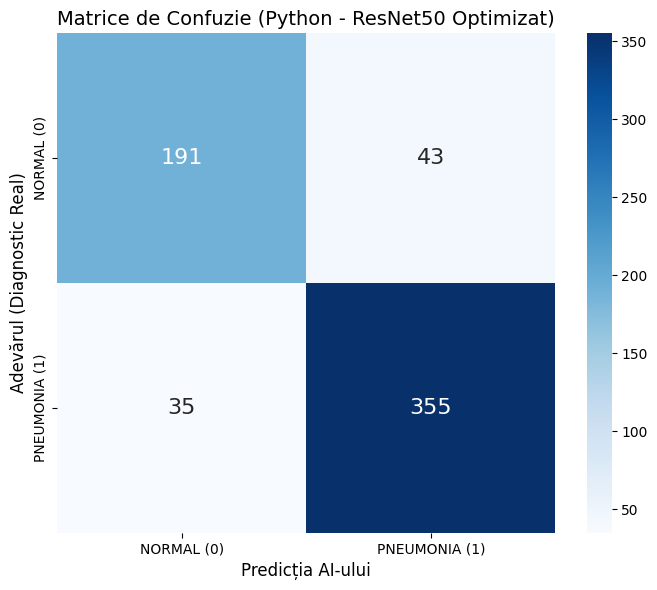

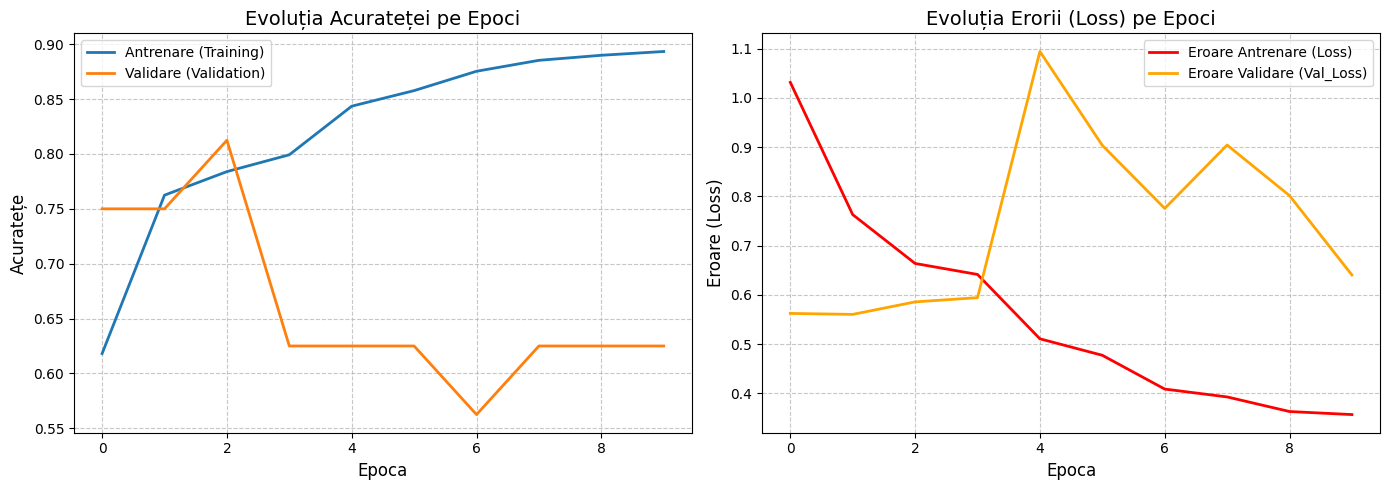


Ambele grafice au fost salvate ca imagini de înaltă rezoluție în Google Drive-ul tău!


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# 1. GENERARE MATRICE DE CONFUZIE
print("Generăm Matricea de Confuzie pe setul de Test...")
test_generator.reset() # Important: resetăm setul ca să nu încurce pozele
predictions = model_final.predict(test_generator)
y_pred = np.where(predictions > 0.5, 1, 0).flatten() # Prag la 50%
y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NORMAL (0)', 'PNEUMONIA (1)'],
            yticklabels=['NORMAL (0)', 'PNEUMONIA (1)'],
            annot_kws={"size": 16})
plt.title('Matrice de Confuzie (Python - ResNet50 Optimizat)', fontsize=14)
plt.ylabel('Adevărul (Diagnostic Real)', fontsize=12)
plt.xlabel('Predicția AI-ului', fontsize=12)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Matrice_Confuzie_Python.png', dpi=300) # O salvăm direct HD în Drive!
plt.show()

# 2. GENERARE GRAFIC CURBĂ DE ÎNVĂȚARE (Loss și Accuracy)
# Notă: Vom trasa datele doar de la Faza 2 (Reglajul Fin) pentru claritate
plt.figure(figsize=(14, 5))

# Sub-graficul 1: Acuratețea
plt.subplot(1, 2, 1)
plt.plot(model_final.history.history['accuracy'], label='Antrenare (Training)', linewidth=2)
plt.plot(model_final.history.history['val_accuracy'], label='Validare (Validation)', linewidth=2)
plt.title('Evoluția Acurateței pe Epoci', fontsize=14)
plt.xlabel('Epoca', fontsize=12)
plt.ylabel('Acuratețe', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Sub-graficul 2: Eroarea (Loss)
plt.subplot(1, 2, 2)
plt.plot(model_final.history.history['loss'], label='Eroare Antrenare (Loss)', color='red', linewidth=2)
plt.plot(model_final.history.history['val_loss'], label='Eroare Validare (Val_Loss)', color='orange', linewidth=2)
plt.title('Evoluția Erorii (Loss) pe Epoci', fontsize=14)
plt.xlabel('Epoca', fontsize=12)
plt.ylabel('Eroare (Loss)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Grafic_Performanta_Python.png', dpi=300) # Salvare HD în Drive
plt.show()
print("\nAmbele grafice au fost salvate ca imagini de înaltă rezoluție în Google Drive-ul tău!")

Se încarcă modelul AI (te rog așteaptă câteva secunde)...


Modelul este pregătit pentru pacienți!

>>> APASĂ BUTONUL DE MAI JOS PENTRU A ÎNCĂRCA O RADIOGRAFIE <<<


Saving N4chestxray.jpeg to N4chestxray.jpeg


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


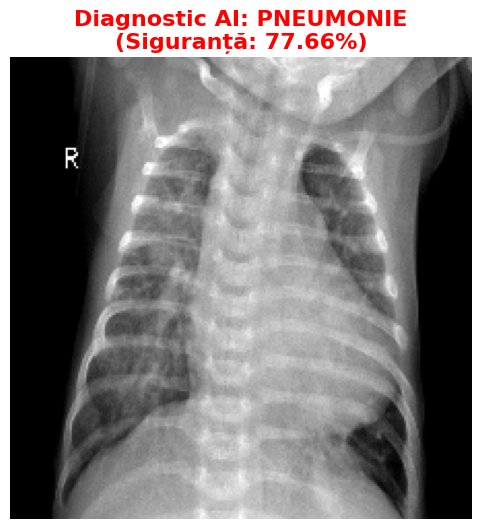

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
from google.colab import files
import os

# 1. Încărcăm modelul suprem salvat adineauri
model_path = '/content/drive/MyDrive/ModelPneumonie_Python_FINAL.h5'
print("Se încarcă modelul AI (te rog așteaptă câteva secunde)...")
model_demo = load_model(model_path)
print("Modelul este pregătit pentru pacienți!\n")

# 2. Afișăm butonul de Upload pentru a alege poza din calculator
print(">>> APASĂ BUTONUL DE MAI JOS PENTRU A ÎNCĂRCA O RADIOGRAFIE <<<")
uploaded = files.upload()

# 3. AI-ul analizează poza (sau pozele) încărcate
for fn in uploaded.keys():
    # Citim poza și o redimensionăm exact cum îi place lui ResNet50
    img = image.load_img(fn, target_size=(224, 224))

    # Transformăm poza în cifre și o normalizăm (foarte important!)
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = x / 255.0

    # AI-ul dă verdictul
    predictie = model_demo.predict(x)
    scor = predictie[0][0] # Rezultatul este un număr între 0 și 1

    # Traducem scorul matematic în limbaj medical
    if scor >= 0.5:
        diagnostic = "PNEUMONIE"
        siguranta = scor * 100
        culoare = 'red' # Roșu pentru boală
    else:
        diagnostic = "NORMAL"
        siguranta = (1 - scor) * 100
        culoare = 'green' # Verde pentru sănătos

    # 4. Afișăm poza mare pe ecran cu diagnosticul
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis('off') # Ascundem axele graficului ca să arate a poză medicală curată

    titlu = f'Diagnostic AI: {diagnostic}\n(Siguranță: {siguranta:.2f}%)'
    plt.title(titlu, fontsize=16, color=culoare, fontweight='bold')
    plt.show()

    # Curățăm poza din memoria temporară pentru a face loc următoarei
    os.remove(fn)